
# Introduction to Data Science - Assignment 1
**Author:** Yahav Alkoby  
**Institution:** HIT - Holon Institute of Technology  
**Dataset:** Google Smartphone Decimeter Challenge (`device_gnss_p4xl_train.csv`)

## Exploratory Data Analysis (EDA) of Raw GNSS Telemetry
This notebook follows a structured, modular approach to Exploratory Data Analysis. We break down the analysis into the following phases:
1. **Environment Setup & Data Loading**
2. **Structural Meta-Analysis & Data Integrity**
3. **Univariate Statistics & Outlier Detection**
4. **Bivariate Analysis & Correlations (Pearson, Spearman, Cramér's V)**
5. **Comprehensive Visualizations Suite**
6. **Time-Series Indexing & Signal Tracking**
7. **Domain Feature Engineering**
    



---
## 1. Environment Setup
We begin by importing the core data science libraries. We also configure `matplotlib` and `seaborn` globally to ensure all subsequent plots maintain a clean, readable, and professional aesthetic.
    


In [1]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Configure visualization settings globally
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
warnings.filterwarnings("ignore")

print("Environment setup completed successfully.")


Environment setup completed successfully.



---
## 2. Data Loading & Meta-Analysis
In this section, we load the GNSS telemetry data into a Pandas DataFrame. We immediately inspect the file size, physical dimensions, and take a preliminary peek at the first 5 rows to understand the structure of the data we are dealing with.
    


In [2]:
file_path = "device_gnss_train_p4xl.csv"  # Ensure this file is in your working directory

try:
    file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
    df = pd.read_csv(file_path)

    print(f"File Name: {os.path.basename(file_path)}")
    print(f"File Size: {file_size_mb:.2f} MB")
    print(f"Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")

    display(df.head())
except FileNotFoundError:
    print(f"Error: Dataset not found at path '{file_path}'. Please verify the file location.")


File Name: device_gnss_train_p4xl.csv
File Size: 30.55 MB
Dimensions: 48,481 rows x 58 columns


,MessageType,utcTimeMillis,TimeNanos,LeapSecond,TimeUncertaintyNanos,FullBiasNanos,BiasNanos,BiasUncertaintyNanos,DriftNanosPerSecond,DriftUncertaintyNanosPerSecond,...,SvVelocityYEcefMetersPerSecond,SvVelocityZEcefMetersPerSecond,SvClockBiasMeters,SvClockDriftMetersPerSecond,IsrbMeters,IonosphericDelayMeters,TroposphericDelayMeters,WlsPositionXEcefMeters,WlsPositionYEcefMeters,WlsPositionZEcefMeters
0,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,45.224788,2921.185153,-114240.988444,-0.002747,0.0,2.990955,3.331083,-2.692779e+06,-4.297235e+06,3.855231e+06
1,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,2683.345352,728.348308,6344.270928,0.000551,0.0,4.233148,9.595780,-2.692779e+06,-4.297235e+06,3.855231e+06
2,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,2112.145384,1639.422495,-66543.908262,-0.000458,0.0,3.189828,4.111674,-2.692779e+06,-4.297235e+06,3.855231e+06
3,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,-728.869571,-2495.102357,-52349.704391,-0.001108,0.0,4.307071,5.539308,-2.692779e+06,-4.297235e+06,3.855231e+06
4,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,-1692.724867,-1274.062821,68762.683069,0.003014,0.0,2.381465,2.830852,-2.692779e+06,-4.297235e+06,3.855231e+06



### 2.1 Null Values and Data Types
A critical first step in EDA is understanding data completeness. Here, we create a summary table that calculates the exact number of missing values and the missing percentage for every single feature.
    


In [3]:
# Generate a metadata dataframe
meta_df = pd.DataFrame({
    "Data_Type": df.dtypes,
    "Non_Null_Count": df.notnull().sum(),
    "Null_Count": df.isnull().sum(),
    "Null_Percentage": (df.isnull().sum() / len(df)) * 100,
    "Unique_Values": df.nunique()
})

# Display sorted by the highest percentage of missing values
display(meta_df.sort_values(by="Null_Percentage", ascending=False))


,Data_Type,Non_Null_Count,Null_Count,Null_Percentage,Unique_Values
TimeUncertaintyNanos,float64,0,48481,100.000000,0
CarrierPhaseUncertainty,float64,0,48481,100.000000,0
CarrierCycles,float64,0,48481,100.000000,0
CarrierPhase,float64,0,48481,100.000000,0
SatelliteInterSignalBiasNanos,float64,0,48481,100.000000,0
FullInterSignalBiasUncertaintyNanos,float64,0,48481,100.000000,0
BasebandCn0DbHz,float64,0,48481,100.000000,0
FullInterSignalBiasNanos,float64,0,48481,100.000000,0
AgcDb,float64,0,48481,100.000000,0
SnrInDb,float64,0,48481,100.000000,0



---
## 3. Data Quality & Integrity Constraints
For cyber-physical data like GNSS logs, variables must adhere to real-world physics. 
* **Elevation:** A satellite cannot have a negative elevation degree relative to the receiver.
* **C/N0 (Carrier-to-Noise):** Typical tracking thresholds fall between 10 and 60 dB-Hz. Signals outside this bounds usually indicate hardware errors or extreme noise.
* **Duplicates:** We check for exact row repetitions.
    


In [4]:
print("--- Data Integrity Check ---")

# 1. Duplicates
full_duplicates = df.duplicated().sum()
print(f"Full Row Duplicates: {full_duplicates:,}")

# 2. Impossible Elevation
if "SvElevationDegrees" in df.columns:
    invalid_elevation = df[df["SvElevationDegrees"] < 0]
    print(f"Suspicious Elevation Entries (<0 deg): {len(invalid_elevation):,}")

# 3. Abnormal Signal Strength
if "Cn0DbHz" in df.columns:
    suspicious_cn0 = df[(df["Cn0DbHz"] < 10) | (df["Cn0DbHz"] > 60)]
    print(f"Suspicious C/N0 Signal Entries (<10 or >60 dB-Hz): {len(suspicious_cn0):,}")

# 4. Zero Variance Columns (Features that offer no informational value)
print("\nColumns with Zero Variance (Constant values):")
display(meta_df[meta_df["Unique_Values"] <= 1][["Data_Type", "Unique_Values"]])


--- Data Integrity Check ---
Full Row Duplicates: 0
Suspicious Elevation Entries (<0 deg): 0
Suspicious C/N0 Signal Entries (<10 or >60 dB-Hz): 0

Columns with Zero Variance (Constant values):


,Data_Type,Unique_Values
MessageType,str,1
LeapSecond,int64,1
TimeUncertaintyNanos,float64,0
HardwareClockDiscontinuityCount,int64,1
TimeOffsetNanos,float64,1
CarrierCycles,float64,0
CarrierPhase,float64,0
CarrierPhaseUncertainty,float64,0
MultipathIndicator,int64,1
SnrInDb,float64,0



---
## 4. Univariate Analysis & Outlier Detection
We focus on `Cn0DbHz` (Carrier-to-Noise Density) as our primary numerical target. We will extract fundamental descriptive statistics (Mean, Median, Mean Absolute Deviation, Skewness). 

Following the statistics, we apply **three distinct outlier methodologies**:
1. **Standard Z-Score** ($|Z| > 3$) - Best for perfectly normal distributions.
2. **Tukey's IQR** ($1.5 \times \text{IQR}$) - Robust against extreme values.
3. **Modified Z-Score (MAD)** - Highly robust median-based approach.
    


In [5]:
target = "Cn0DbHz"
series = df[target].dropna()

# Descriptive Statistics
mean_val = series.mean()
median_val = series.median()
std_val = series.std()
mad_val = (series - median_val).abs().mean()
iqr_val = series.quantile(0.75) - series.quantile(0.25)
skewness = series.skew()

print(f"--- Descriptive Statistics for {target} ---")
print(f"Mean: {mean_val:.2f}  | Median: {median_val:.2f} | Std Dev: {std_val:.2f}")
print(f"MAD:  {mad_val:.2f}  | IQR:    {iqr_val:.2f} | Skewness: {skewness:.2f}")
print(f"Min:  {series.min():.2f}  | Max:    {series.max():.2f}\n")

# Outlier Method 1: Z-Score
z_scores = np.abs(stats.zscore(series))
outliers_z = series[z_scores > 3]

# Outlier Method 2: IQR
q1, q3 = series.quantile(0.25), series.quantile(0.75)
outliers_iqr = series[(series < (q1 - 1.5 * iqr_val)) | (series > (q3 + 1.5 * iqr_val))]

# Outlier Method 3: Modified Z-Score
median_absolute_deviation = np.median(np.abs(series - median_val))
mod_z_scores = 0.6745 * np.abs(series - median_val) / (median_absolute_deviation + 1e-9)
outliers_mad = series[mod_z_scores > 3.5]

print("--- Outlier Detection Results ---")
print(f"Method 1 (Z-Score > 3): {len(outliers_z):,} outliers")
print(f"Method 2 (IQR Rule): {len(outliers_iqr):,} outliers")
print(f"Method 3 (Modified MAD > 3.5): {len(outliers_mad):,} outliers")


--- Descriptive Statistics for Cn0DbHz ---
Mean: 33.71  | Median: 34.20 | Std Dev: 5.32
MAD:  4.33  | IQR:    7.60 | Skewness: -0.41
Min:  13.70  | Max:    47.80

--- Outlier Detection Results ---
Method 1 (Z-Score > 3): 59 outliers
Method 2 (IQR Rule): 131 outliers
Method 3 (Modified MAD > 3.5): 4 outliers



---
## 5. Bivariate Analysis: Correlations & Cramér's V
To understand how variables interact, we calculate Pearson (linear) and Spearman (monotonic) correlations for continuous data.

Because `SignalType` is categorical and `Cn0DbHz` is continuous, standard correlation fails. We solve this by discretizing `Cn0DbHz` into quartiles and applying **Cramér's V**, a statistic used to measure association between categorical nominal variables.
    


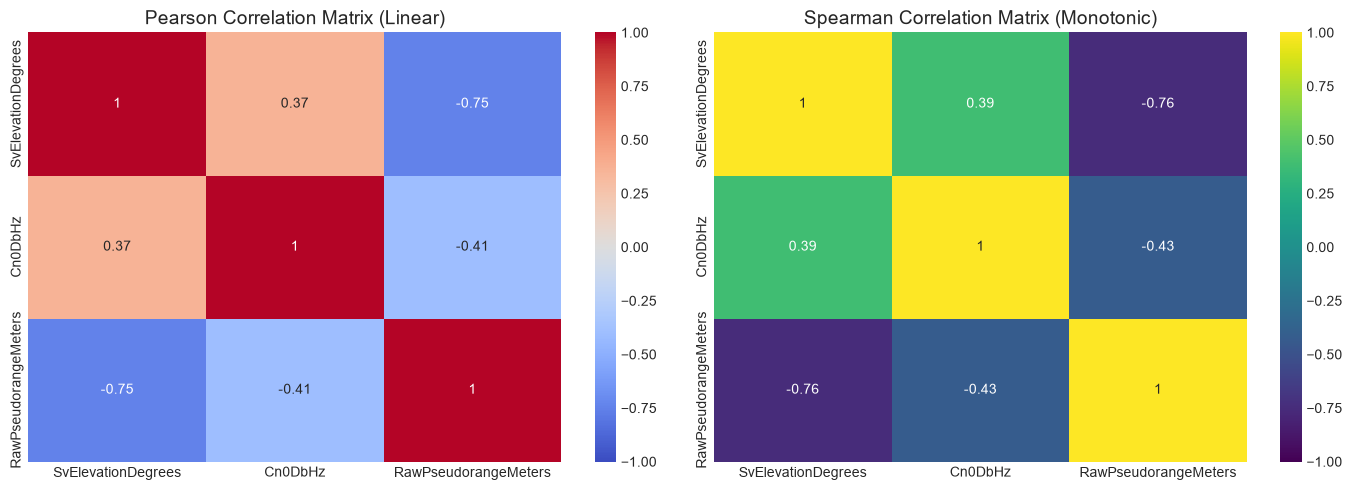

Cramér's V Correlation (SignalType vs Binned C/N0): 0.170


Signal_Strength_Bin,Weak,Moderate,Strong,Excellent
SignalType,,,,
GAL_E1_C_P,2581,2926,2477,2036
GAL_E5A_Q,3719,3187,2630,499
GLO_G1_CA,1816,2132,1795,2721
GPS_L1_CA,3012,2835,3363,5068
GPS_L5_Q,922,965,1790,1761


In [6]:
# 5.1 Continuous Correlations
num_cols = ["SvElevationDegrees", "Cn0DbHz", "RawPseudorangeMeters"]
num_df = df[num_cols].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(num_df.corr(method="pearson"), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson Correlation Matrix (Linear)")

sns.heatmap(num_df.corr(method="spearman"), annot=True, cmap="viridis", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman Correlation Matrix (Monotonic)")

plt.tight_layout()
plt.show()

# 5.2 Categorical Correlation (Cramér's V)
df_binned = df.copy()
df_binned["Signal_Strength_Bin"] = pd.qcut(df_binned["Cn0DbHz"], q=4, labels=["Weak", "Moderate", "Strong", "Excellent"])
contingency = pd.crosstab(df_binned["SignalType"], df_binned["Signal_Strength_Bin"])

chi2 = stats.chi2_contingency(contingency)[0]
n = contingency.sum().sum()
phi2 = chi2 / n
r, k = contingency.shape
v_stat = np.sqrt(phi2 / min(k - 1, r - 1))

print(f"Cramér's V Correlation (SignalType vs Binned C/N0): {v_stat:.3f}")
display(contingency)



---
## 6. Comprehensive Visualizations Suite
Visualizing the distributions and interactions allows us to spot data skews, signal degradation patterns, and constellation biases.
    


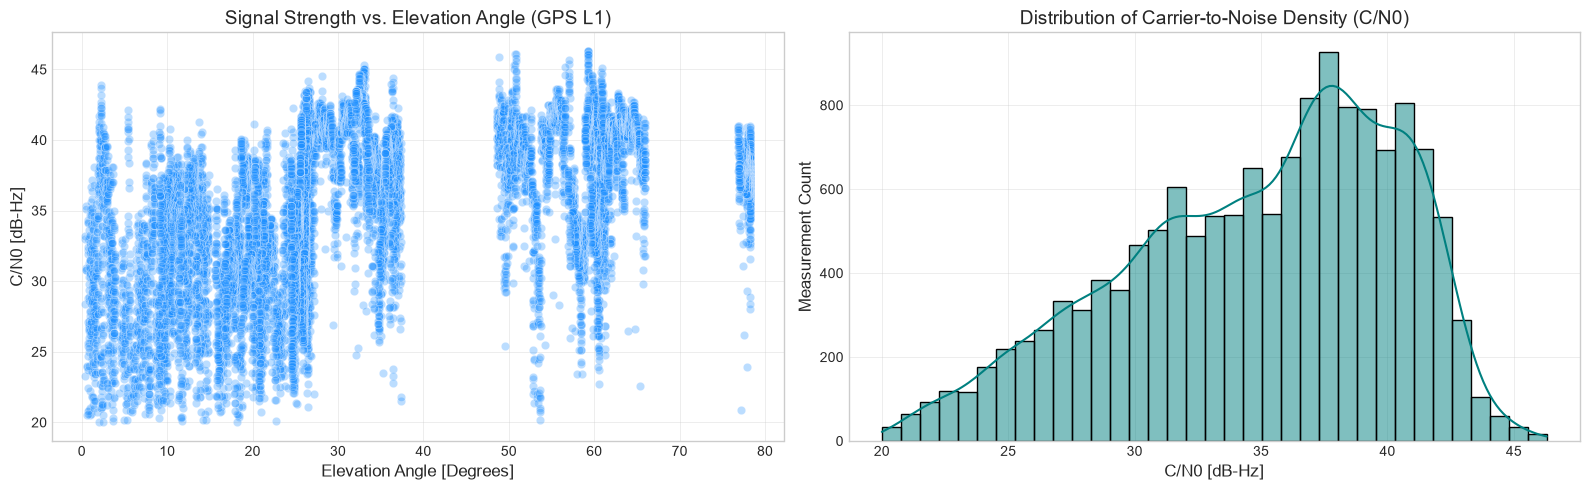

In [7]:
# Filter GPS L1 satellites for a clean physical representation
clean_gps = df[(df["ConstellationType"] == 1) & (df["SignalType"] == "GPS_L1_CA")].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Elevation vs Signal Strength
sns.scatterplot(data=clean_gps, x="SvElevationDegrees", y="Cn0DbHz", alpha=0.3, color="dodgerblue", ax=axes[0])
axes[0].set_title("Signal Strength vs. Elevation Angle (GPS L1)")
axes[0].set_xlabel("Elevation Angle [Degrees]")
axes[0].set_ylabel("C/N0 [dB-Hz]")

# Plot 2: C/N0 Distribution
sns.histplot(clean_gps["Cn0DbHz"], bins=35, kde=True, color="teal", ax=axes[1])
axes[1].set_title("Distribution of Carrier-to-Noise Density (C/N0)")
axes[1].set_xlabel("C/N0 [dB-Hz]")
axes[1].set_ylabel("Measurement Count")

plt.tight_layout()
plt.show()



### 6.1 Constellation & Signal Comparisons
How do different satellite systems (GPS, GLONASS, Galileo) compare in terms of signal strength and elevation availability?
    


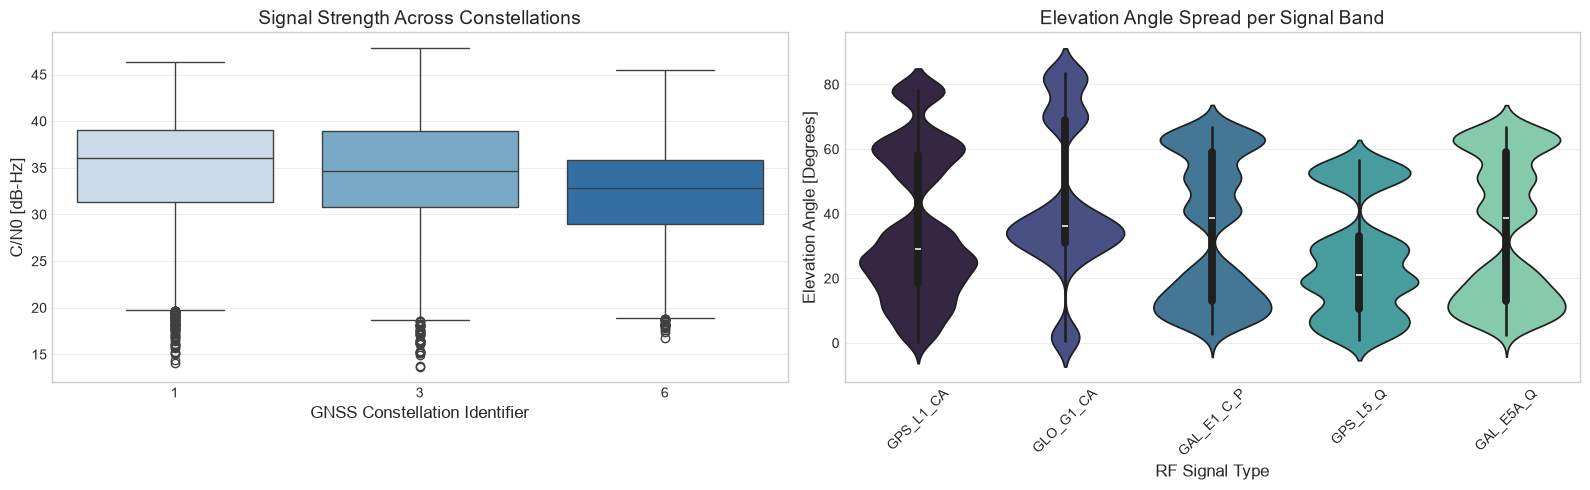

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 3: Boxplot of C/N0 by Constellation
sns.boxplot(data=df, x="ConstellationType", y="Cn0DbHz", palette="Blues", ax=axes[0])
axes[0].set_title("Signal Strength Across Constellations")
axes[0].set_xlabel("GNSS Constellation Identifier")
axes[0].set_ylabel("C/N0 [dB-Hz]")

# Plot 4: Violinplot of Elevation by Signal Type
sns.violinplot(data=df, x="SignalType", y="SvElevationDegrees", palette="mako", ax=axes[1])
axes[1].set_title("Elevation Angle Spread per Signal Band")
axes[1].set_xlabel("RF Signal Type")
axes[1].set_ylabel("Elevation Angle [Degrees]")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



---
## 7. Time-Series Tracking & Stability
We analyze signal stability over time. Specifically, we isolate the satellite with the *highest* standard deviation in signal strength (most volatile) and the one with the *lowest* (most stable).
    


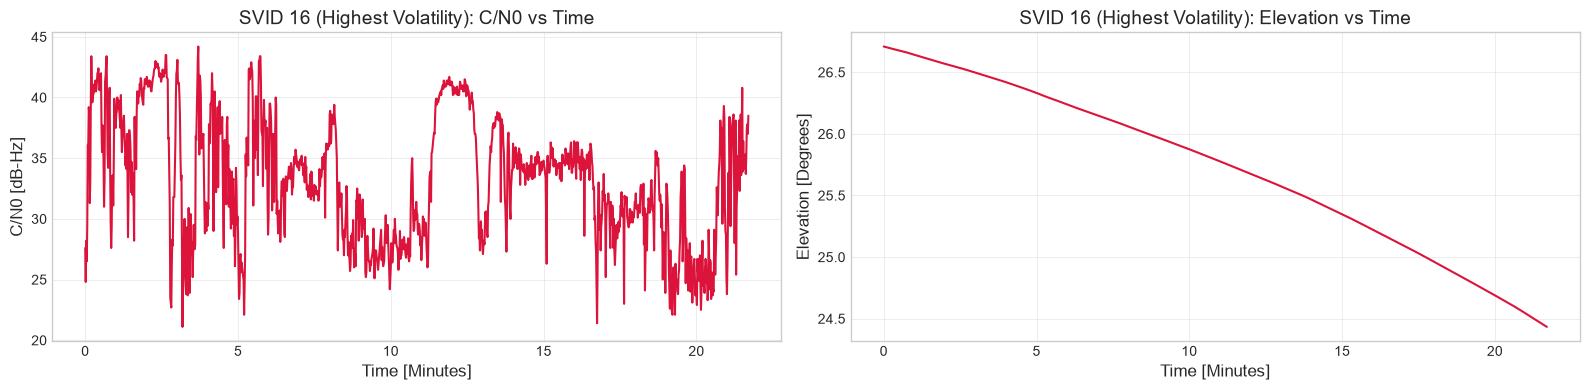

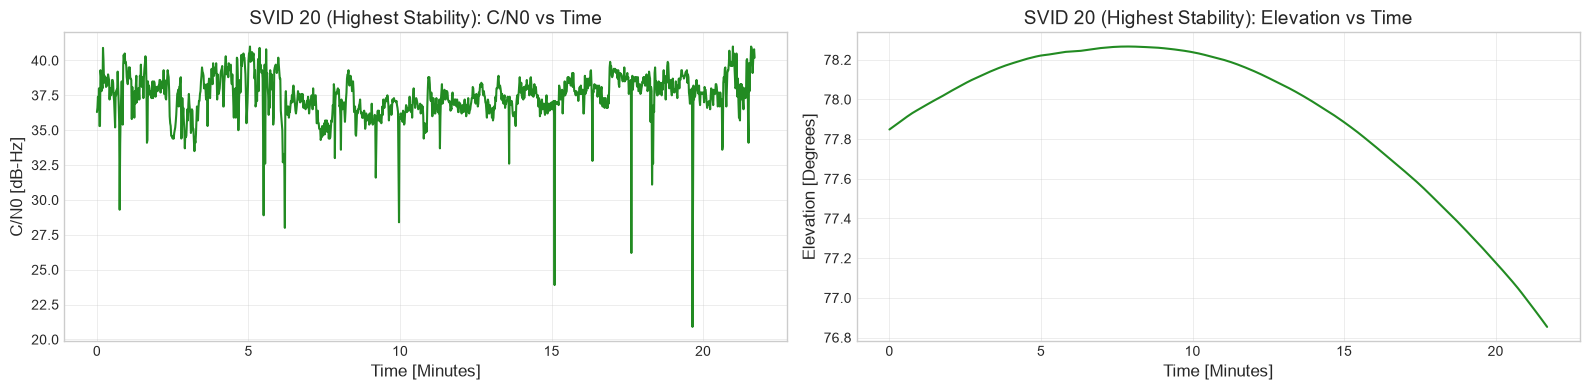

In [9]:
gps_l1 = df[(df["ConstellationType"] == 1) & (df["SignalType"] == "GPS_L1_CA")].copy()

# Filter out satellites with too few observations for valid std calculation
valid_svids = gps_l1.groupby("Svid")["Cn0DbHz"].count()[lambda x: x >= 50].index
gps_l1_filtered = gps_l1[gps_l1["Svid"].isin(valid_svids)]

# Calculate standard deviation per satellite
std_per_svid = gps_l1_filtered.groupby("Svid")["Cn0DbHz"].std()
svid_most_volatile = std_per_svid.idxmax()
svid_most_stable = std_per_svid.idxmin()

def plot_svid_time_series(svid, title_suffix, color):
    data = gps_l1_filtered[gps_l1_filtered["Svid"] == svid].copy()
    data['TimeMinutes'] = (data['TimeNanos'] - data['TimeNanos'].min()) / 1e9 / 60

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    sns.lineplot(data=data, x="TimeMinutes", y="Cn0DbHz", color=color, ax=axes[0])
    axes[0].set_title(f"SVID {svid} ({title_suffix}): C/N0 vs Time")
    axes[0].set_xlabel("Time [Minutes]")
    axes[0].set_ylabel("C/N0 [dB-Hz]")

    sns.lineplot(data=data, x="TimeMinutes", y="SvElevationDegrees", color=color, ax=axes[1])
    axes[1].set_title(f"SVID {svid} ({title_suffix}): Elevation vs Time")
    axes[1].set_xlabel("Time [Minutes]")
    axes[1].set_ylabel("Elevation [Degrees]")

    plt.tight_layout()
    plt.show()

# Plot the most volatile and most stable satellites
plot_svid_time_series(svid_most_volatile, "Highest Volatility", "crimson")
plot_svid_time_series(svid_most_stable, "Highest Stability", "forestgreen")



---
## 8. Index Structure & Monotonicity
For sequential GNSS data, ensuring the data is strictly ordered in time without index duplicates is critical before applying smoothing filters like Kalman Filters.
    


In [10]:
print(f"Is DataFrame Index Unique? -> {df.index.is_unique}")
print(f"Is DataFrame Index Monotonically Increasing? -> {df.index.is_monotonic_increasing}")

if "ReceivedSvTimeNanosSinceGpsEpoch" in df.columns:
    is_time_sorted = df["ReceivedSvTimeNanosSinceGpsEpoch"].is_monotonic_increasing
    print(f"Is Dataset Monotonically Sorted by GPS Time? -> {is_time_sorted}")
else:
    print("Column 'ReceivedSvTimeNanosSinceGpsEpoch' not found for strict time check.")


Is DataFrame Index Unique? -> True
Is DataFrame Index Monotonically Increasing? -> True
Is Dataset Monotonically Sorted by GPS Time? -> False



---
## 9. Domain Feature Engineering (Bonus)
A major objective of processing GNSS data is identifying **Line-of-Sight (LOS)** vs. **Multipath** signals. Multipath occurs when signals bounce off buildings, degrading location accuracy.

We engineer a new boolean feature `Is_Reliable_LOS`. Based on domain knowledge, a signal is generally considered a reliable LOS if:
1. It is high in the sky ($\geq 40^\circ$) reducing the chance of hitting buildings.
2. It has a strong signal-to-noise ratio ($\geq 37$ dB-Hz).
    


Reliable Line-of-Sight (LOS) Measurements in Dataset: 16.71%


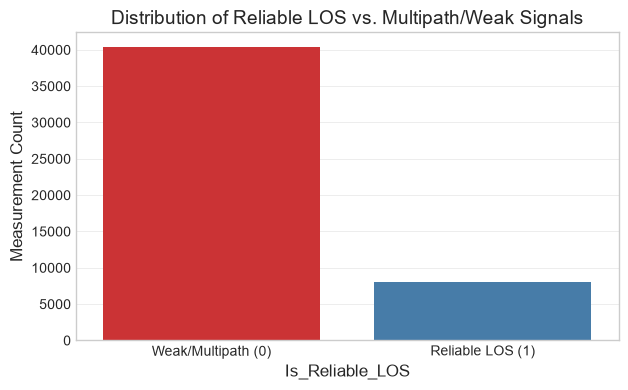

EDA Pipeline Complete.


In [11]:
# Engineer the new feature
df["Is_Reliable_LOS"] = np.where(
    (df["SvElevationDegrees"] >= 40) & (df["Cn0DbHz"] >= 37),
    1, 
    0
)

los_percentage = df["Is_Reliable_LOS"].mean() * 100
print(f"Reliable Line-of-Sight (LOS) Measurements in Dataset: {los_percentage:.2f}%")

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Is_Reliable_LOS", palette="Set1")
plt.title("Distribution of Reliable LOS vs. Multipath/Weak Signals")
plt.xticks(ticks=[0, 1], labels=["Weak/Multipath (0)", "Reliable LOS (1)"])
plt.ylabel("Measurement Count")
plt.show()

print("EDA Pipeline Complete.")
